# Stock Transformer — end-to-end run

Predict SPY's next-day candle (open, high, low, close) using a transformer that treats each `(ticker, day)` candle as a token.

This notebook runs the full pipeline against the data cached under `data/`:

1. Load OHLCV from `data/processed/ohlcv.parquet` (no API calls required).
2. Explore the universe and overlay macro context (CPI, fed funds, 10-yr treasury).
3. Build features, split chronologically, and train the `CandleTransformer`.
4. Evaluate on the held-out test set and visualize predictions.
5. Predict the very next trading day's SPY candle from the latest available window.

If `data/processed/ohlcv.parquet` does not yet exist, run the bulk-download pipeline first — see the *Bulk download* section in the README.

## 0. Setup

Make `src/` importable, load environment variables, set seed and device.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").is_dir() and str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from stock_transformer.data import align_universe
from stock_transformer.features import build_features
from stock_transformer.model import CandleTransformer
from stock_transformer.train import (
    evaluate,
    get_device,
    seed_everything,
    split_data,
    train_model,
)

load_dotenv()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OHLCV_PARQUET = PROCESSED_DIR / "ohlcv.parquet"
MACRO_DIR = PROCESSED_DIR / "macro"

print(f"Project root: {PROJECT_ROOT}")
print(f"OHLCV parquet exists: {OHLCV_PARQUET.is_file()} ({OHLCV_PARQUET})")
print(f"torch:  {torch.__version__}")
print(f"numpy:  {np.__version__}")
print(f"pandas: {pd.__version__}")

Project root: /Users/dev/Documents/stock-transformer
OHLCV parquet exists: True (/Users/dev/Documents/stock-transformer/data/processed/ohlcv.parquet)
torch:  2.11.0
numpy:  2.4.4
pandas: 3.0.2


In [2]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"
with open(CONFIG_PATH) as f:
    cfg: dict = yaml.safe_load(f)

# Notebook-friendly overrides (edit here, no need to touch the yaml)
cfg.setdefault("symbols", ["SPY", "QQQ", "AAPL", "MSFT", "GOOGL"])
cfg.setdefault("target_symbol", "SPY")
# Optional: clip the OHLCV history (None = use everything available)
cfg.setdefault("start_date", "2010-01-01")
cfg.setdefault("end_date", None)

seed_everything(cfg["seed"])
device = get_device()

print(f"Config:        {CONFIG_PATH.relative_to(PROJECT_ROOT)}")
print(f"Device:        {device}")
print(f"Symbols:       {cfg['symbols']}")
print(f"Target symbol: {cfg['target_symbol']}")
print(f"Lookback:      {cfg['lookback']} days")
print(f"Date range:    {cfg['start_date']} → {cfg['end_date'] or 'latest'}")

Config:        configs/default.yaml
Device:        mps
Symbols:       ['SPY', 'QQQ', 'AAPL', 'MSFT', 'GOOGL']
Target symbol: SPY
Lookback:      30 days
Date range:    2010-01-01 → latest


## 1. Load OHLCV from cache

We read the bulk-downloaded `data/processed/ohlcv.parquet` and pivot it into the per-symbol shape that `align_universe` and `build_features` expect:

```python
{symbol: DataFrame(columns=[timestamp, open, high, low, close, volume])}
```

`adjusted_close` is used as `close` (matches the original `_parse_daily` behavior — splits and dividends already baked in).

In [3]:
def load_universe_from_parquet(
    symbols: list[str],
    parquet_path: Path,
    start_date: str | None = None,
    end_date: str | None = None,
) -> dict[str, pd.DataFrame]:
    """Read the bulk OHLCV parquet and reshape into the {symbol: candle DataFrame} format.

    Output schema mirrors :func:`stock_transformer.data.fetch_universe`.
    """
    if not parquet_path.is_file():
        raise FileNotFoundError(
            f"{parquet_path} is missing — run `python scripts/download_data.py` first "
            "(or fall back to `fetch_universe` for a small online fetch)."
        )

    wanted = [s.upper() for s in symbols]
    df = pd.read_parquet(parquet_path, columns=[
        "symbol", "date", "open", "high", "low", "adjusted_close", "volume",
    ])
    df = df[df["symbol"].isin(wanted)].copy()

    missing = sorted(set(wanted) - set(df["symbol"].unique()))
    if missing:
        raise KeyError(f"Symbols missing from {parquet_path.name}: {missing}")

    if start_date is not None:
        df = df[df["date"] >= pd.Timestamp(start_date)]
    if end_date is not None:
        df = df[df["date"] <= pd.Timestamp(end_date)]

    df = df.rename(columns={"date": "timestamp", "adjusted_close": "close"})
    df = df[["symbol", "timestamp", "open", "high", "low", "close", "volume"]]

    out: dict[str, pd.DataFrame] = {}
    for sym in wanted:
        sub = (
            df[df["symbol"] == sym]
            .drop(columns="symbol")
            .sort_values("timestamp")
            .reset_index(drop=True)
        )
        out[sym] = sub
        print(
            f"  {sym:<6s} {len(sub):>5d} rows  "
            f"{sub['timestamp'].min().date()} → {sub['timestamp'].max().date()}"
        )
    return out


candles = load_universe_from_parquet(
    cfg["symbols"], OHLCV_PARQUET, cfg["start_date"], cfg["end_date"]
)
aligned = align_universe(candles)

  SPY     4102 rows  2010-01-04 → 2026-04-24
  QQQ     4102 rows  2010-01-04 → 2026-04-24
  AAPL    4102 rows  2010-01-04 → 2026-04-24
  MSFT    4102 rows  2010-01-04 → 2026-04-24
  GOOGL   4102 rows  2010-01-04 → 2026-04-24
  Aligned 5 symbols on 4102 common trading days
  Date range: 2010-01-04 to 2026-04-24


## 2. Explore the universe

Quick sanity checks: SPY price + drawdown, daily-return distribution, and a normalized growth comparison across the chosen symbols.

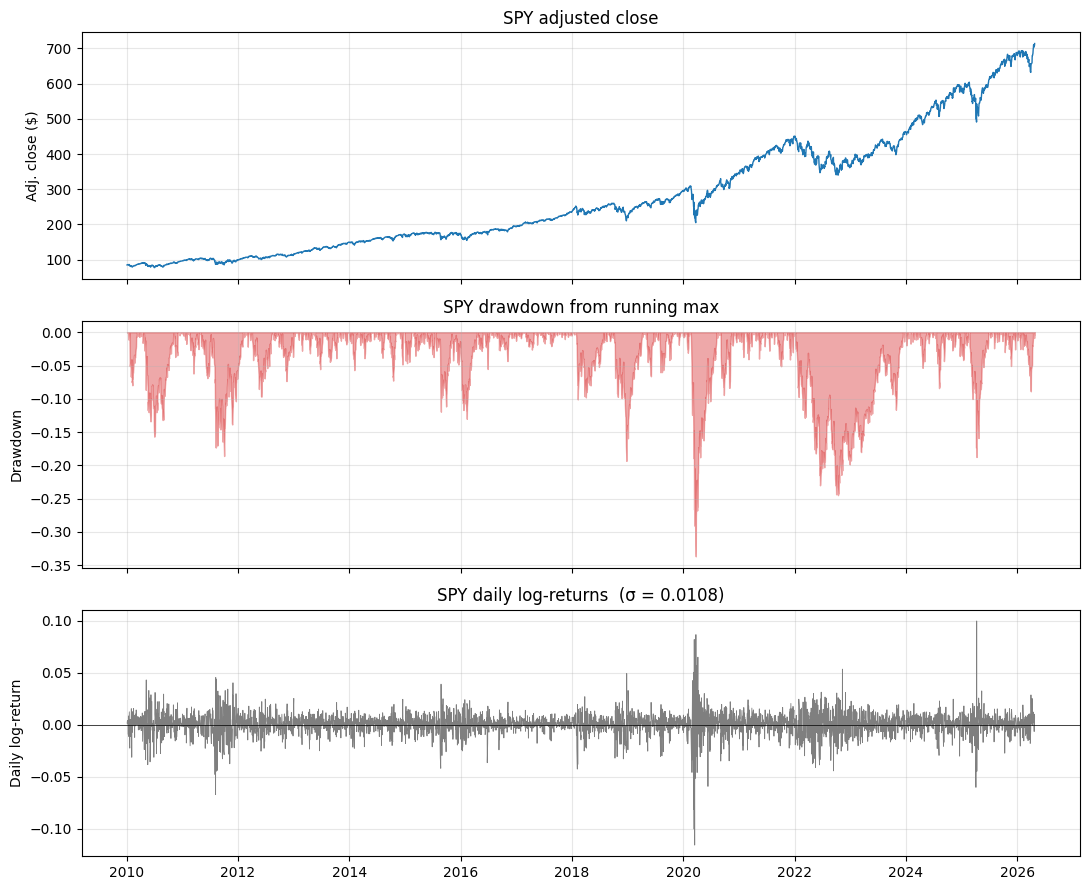

,first,last,rows,avg_close,daily_vol
SPY,2010-01-04,2026-04-24,4102,275.82,0.0108
QQQ,2010-01-04,2026-04-24,4102,208.43,0.0130
AAPL,2010-01-04,2026-04-24,4102,80.93,0.0177
MSFT,2010-01-04,2026-04-24,4102,154.31,0.0162
GOOGL,2010-01-04,2026-04-24,4102,74.91,0.0174


In [4]:
target_sym = cfg["target_symbol"].upper()
spy = aligned[target_sym].set_index("timestamp")
spy_ret = np.log(spy["close"]).diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(spy.index, spy["close"], color="tab:blue", lw=1.0)
axes[0].set_ylabel("Adj. close ($)")
axes[0].set_title(f"{target_sym} adjusted close")
axes[0].grid(alpha=0.3)

running_max = spy["close"].cummax()
drawdown = spy["close"] / running_max - 1.0
axes[1].fill_between(drawdown.index, drawdown.values, 0, color="tab:red", alpha=0.4)
axes[1].set_ylabel("Drawdown")
axes[1].set_title(f"{target_sym} drawdown from running max")
axes[1].grid(alpha=0.3)

axes[2].plot(spy_ret.index, spy_ret.values, color="tab:gray", lw=0.6)
axes[2].axhline(0, color="k", lw=0.5)
axes[2].set_ylabel("Daily log-return")
axes[2].set_title(f"{target_sym} daily log-returns  (σ = {spy_ret.std():.4f})")
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

stats = pd.DataFrame({
    "first": [df["timestamp"].min().date() for df in aligned.values()],
    "last":  [df["timestamp"].max().date() for df in aligned.values()],
    "rows":  [len(df) for df in aligned.values()],
    "avg_close": [df["close"].mean() for df in aligned.values()],
    "daily_vol": [np.log(df["close"]).diff().std() for df in aligned.values()],
}, index=list(aligned.keys()))
stats.style.format({"avg_close": "{:.2f}", "daily_vol": "{:.4f}"})

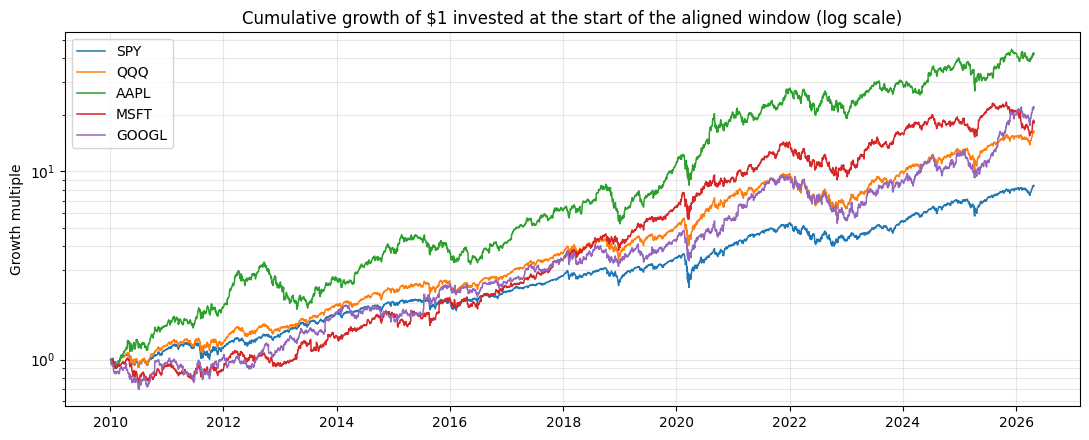

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for sym, df in aligned.items():
    s = df.set_index("timestamp")["close"]
    ax.plot(s.index, s.values / s.iloc[0], lw=1.1, label=sym)
ax.set_yscale("log")
ax.set_title("Cumulative growth of $1 invested at the start of the aligned window (log scale)")
ax.set_ylabel("Growth multiple")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## 3. Macro context

Overlay key macro series alongside SPY: CPI level, the effective fed-funds rate, and the 10-year treasury yield. The transformer doesn't ingest these directly (yet), but eyeballing the regime helps interpret the train/test split.

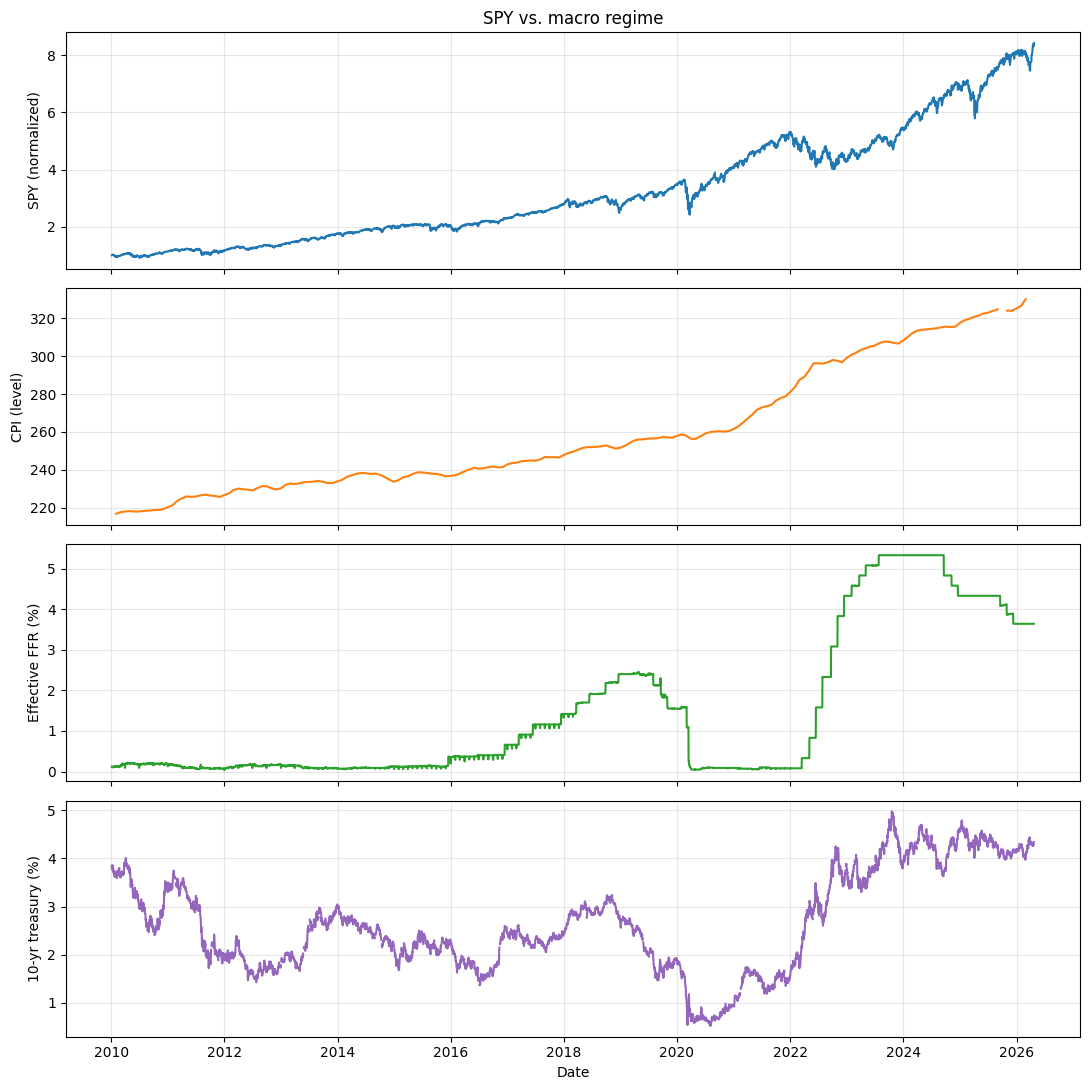

In [6]:
def _load_macro(name: str) -> pd.DataFrame | None:
    p = MACRO_DIR / f"{name}.parquet"
    if not p.is_file():
        print(f"  [skip] {p.name} not found")
        return None
    return pd.read_parquet(p).sort_values("date")


start = spy.index.min()
end = spy.index.max()

cpi = _load_macro("cpi")
ffr = _load_macro("federal_funds_rate")
tsy = _load_macro("treasury_yield")

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

spy_norm = spy["close"] / spy["close"].iloc[0]
axes[0].plot(spy_norm.index, spy_norm.values, color="tab:blue")
axes[0].set_ylabel(f"{target_sym} (normalized)")
axes[0].set_title(f"{target_sym} vs. macro regime")
axes[0].grid(alpha=0.3)

if cpi is not None:
    sub = cpi[(cpi["date"] >= start) & (cpi["date"] <= end)]
    axes[1].plot(sub["date"], sub["value"], color="tab:orange")
axes[1].set_ylabel("CPI (level)")
axes[1].grid(alpha=0.3)

if ffr is not None:
    sub = ffr[(ffr["date"] >= start) & (ffr["date"] <= end)]
    axes[2].plot(sub["date"], sub["value"], color="tab:green")
axes[2].set_ylabel("Effective FFR (%)")
axes[2].grid(alpha=0.3)

if tsy is not None:
    sub = tsy[(tsy["maturity"] == "10year") & (tsy["date"] >= start) & (tsy["date"] <= end)]
    axes[3].plot(sub["date"], sub["value"], color="tab:purple")
axes[3].set_ylabel("10-yr treasury (%)")
axes[3].grid(alpha=0.3)
axes[3].set_xlabel("Date")

fig.tight_layout()
plt.show()

## 4. Build features and split

Each `(ticker, day)` candle is one token. A sample is the last `lookback` days × `n_symbols` tokens, and the label is the target's next-day OHLC expressed as log-returns from today's close.

  Built 4071 samples, each with 30x5=150 tokens
  Target: SPY next-day OHLC log-returns
  Split: train=2849, val=611, test=611

X shape: (4071, 150, 5)  (samples, lookback*n_symbols, features)
y shape: (4071, 4)  (samples, [open, high, low, close] log-returns)
Symbol order: ['SPY', 'QQQ', 'AAPL', 'MSFT', 'GOOGL']


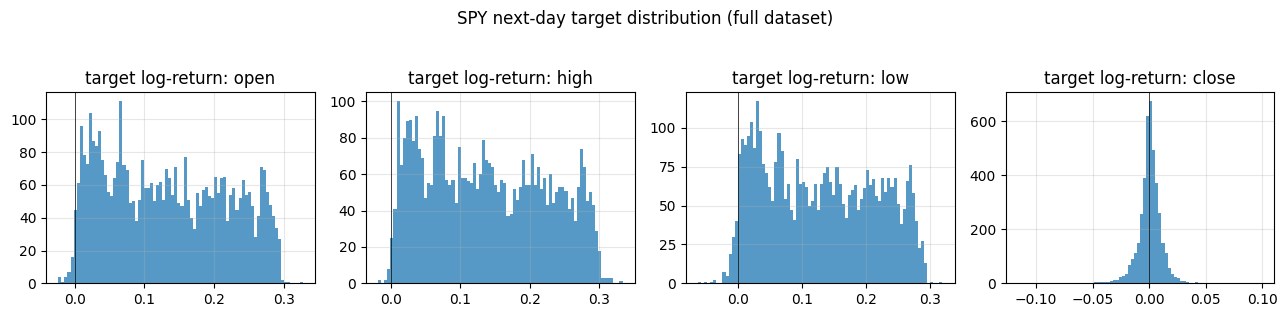

In [7]:
X, y, symbols = build_features(aligned, cfg["target_symbol"], cfg["lookback"])
train_data, val_data, test_data = split_data(X, y, cfg["train_pct"], cfg["val_pct"])

print(f"\nX shape: {tuple(X.shape)}  (samples, lookback*n_symbols, features)")
print(f"y shape: {tuple(y.shape)}  (samples, [open, high, low, close] log-returns)")
print(f"Symbol order: {symbols}")

labels = ["open", "high", "low", "close"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for i, name in enumerate(labels):
    axes[i].hist(y[:, i].numpy(), bins=80, color="tab:blue", alpha=0.75)
    axes[i].set_title(f"target log-return: {name}")
    axes[i].axvline(0, color="k", lw=0.5)
    axes[i].grid(alpha=0.3)
fig.suptitle(f"{cfg['target_symbol']} next-day target distribution (full dataset)", y=1.04)
fig.tight_layout()
plt.show()

## 5. Train the transformer

A tiny `CandleTransformer` (params from `configs/default.yaml`). Training stops early on validation-loss stagnation.

In [8]:
target_idx = symbols.index(cfg["target_symbol"].upper())

model = CandleTransformer(
    n_symbols=len(symbols),
    lookback=cfg["lookback"],
    d_model=cfg["d_model"],
    nhead=cfg["nhead"],
    num_layers=cfg["num_layers"],
    dropout=cfg["dropout"],
    target_symbol_idx=target_idx,
)
total_params = sum(p.numel() for p in model.parameters())
print(
    f"Model: {total_params:,} parameters  |  "
    f"d_model={cfg['d_model']}  nhead={cfg['nhead']}  layers={cfg['num_layers']}"
)

model = train_model(
    model,
    train_data,
    val_data,
    epochs=cfg["epochs"],
    batch_size=cfg["batch_size"],
    learning_rate=cfg["learning_rate"],
    device=device,
)

Model: 152,836 parameters  |  d_model=64  nhead=4  layers=3
  Epoch   1  train=0.016945  val=0.001535 *
  Epoch   2  train=0.003829  val=0.000837 *
  Epoch   3  train=0.002383  val=0.000954
  Epoch   4  train=0.001797  val=0.000451 *
  Epoch   5  train=0.001525  val=0.000576
  Epoch   8  train=0.001113  val=0.000219 *
  Epoch  10  train=0.001001  val=0.000177 *
  Epoch  14  train=0.000684  val=0.000146 *
  Epoch  15  train=0.000636  val=0.000232
  Epoch  16  train=0.000665  val=0.000123 *
  Epoch  20  train=0.000728  val=0.000917
  Early stopping at epoch 21 (no improvement for 5 epochs)


## 6. Evaluate on the held-out test set

Reports per-channel MSE and direction-of-close accuracy, then plots predictions vs. actuals.

In [9]:
evaluate(model, test_data, device)

test_X, test_y = test_data[0].to(device), test_data[1].to(device)
model.eval()
with torch.no_grad():
    test_pred = model(test_X).cpu().numpy()
test_actual = test_y.cpu().numpy()


  === Test Results ===
  MSE  open: 0.000966
  MSE  high: 0.000943
  MSE   low: 0.000772
  MSE close: 0.000105
  MSE total: 0.000697
  Direction accuracy (close): 42.1%
  Test samples: 611


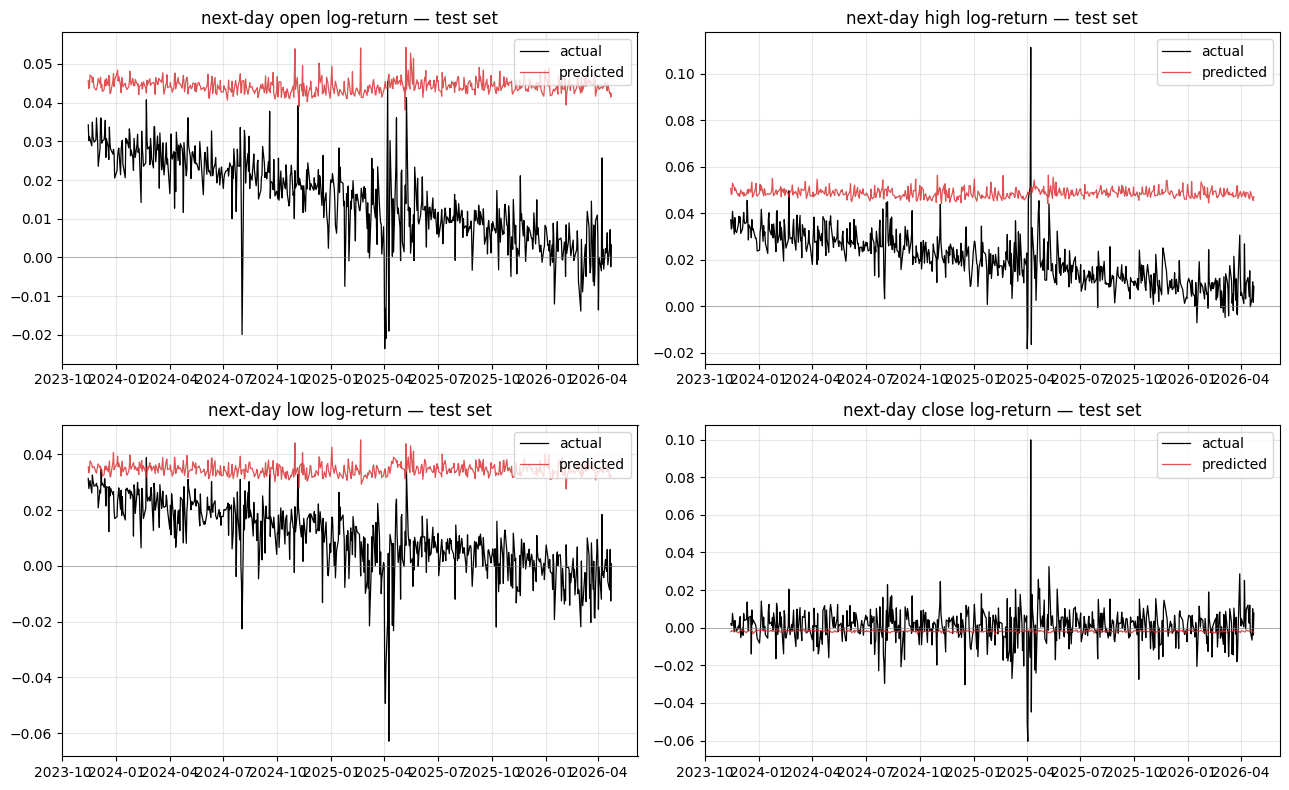

In [10]:
# Recover the dates corresponding to each test sample so plots have an x-axis.
n_total = len(X)
n_train = int(n_total * cfg["train_pct"])
n_val = int(n_total * (cfg["train_pct"] + cfg["val_pct"]))

spy_dates = aligned[target_sym]["timestamp"].reset_index(drop=True)
# build_features uses days [valid_start + lookback - 1, n_days - 1) = [lookback, n_days - 1)
sample_today_dates = spy_dates.iloc[cfg["lookback"] : len(spy_dates) - 1].reset_index(drop=True)
assert len(sample_today_dates) == n_total, (len(sample_today_dates), n_total)
test_dates = sample_today_dates.iloc[n_val:].reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, (name, ax) in enumerate(zip(labels, axes.flat)):
    ax.plot(test_dates, test_actual[:, i], color="k",       lw=0.9, label="actual")
    ax.plot(test_dates, test_pred[:, i],   color="tab:red", lw=0.9, alpha=0.8, label="predicted")
    ax.axhline(0, color="gray", lw=0.4)
    ax.set_title(f"next-day {name} log-return — test set")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

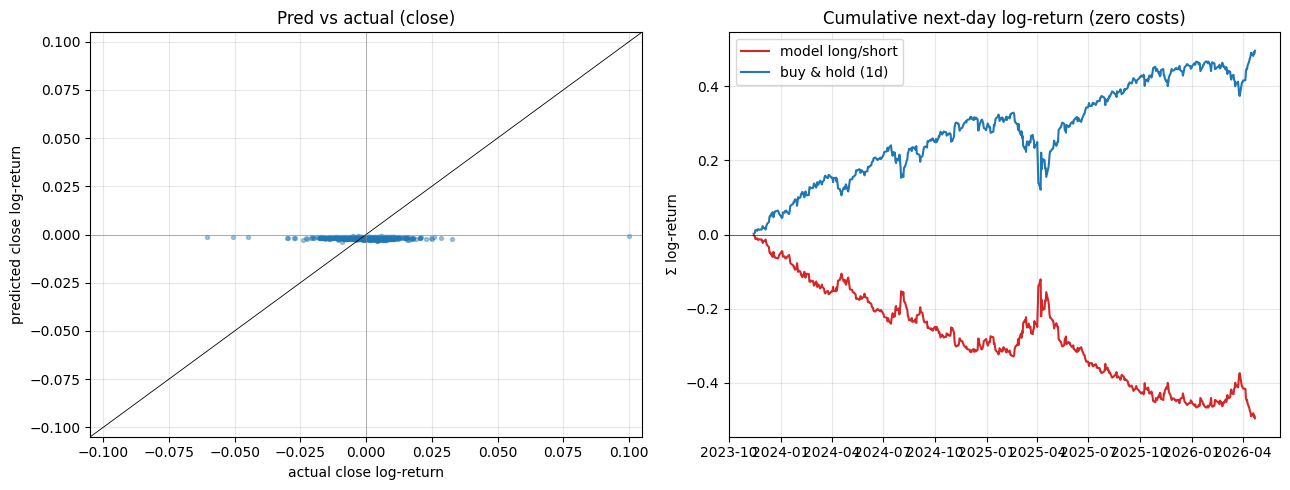

Direction hit rate (close): 42.1%
Cumulative model log-return: -0.4956  →  exp = 0.609x
Cumulative buy-and-hold:     0.4956  →  exp = 1.641x


In [11]:
# Predicted vs actual scatter for the close return + naive long/short PnL.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

p_close = test_pred[:, 3]
a_close = test_actual[:, 3]

lim = max(abs(p_close).max(), abs(a_close).max()) * 1.05
axes[0].scatter(a_close, p_close, s=8, alpha=0.4)
axes[0].plot([-lim, lim], [-lim, lim], color="k", lw=0.6)
axes[0].axhline(0, color="gray", lw=0.4)
axes[0].axvline(0, color="gray", lw=0.4)
axes[0].set_xlim(-lim, lim)
axes[0].set_ylim(-lim, lim)
axes[0].set_xlabel("actual close log-return")
axes[0].set_ylabel("predicted close log-return")
axes[0].set_title("Pred vs actual (close)")
axes[0].grid(alpha=0.3)

# Strategy: long if predicted close return > 0, else short.
# Daily realized log-return = sign(pred) * actual.
position = np.sign(p_close)
daily_pnl = position * a_close
buy_hold = a_close
axes[1].plot(test_dates, np.cumsum(daily_pnl), color="tab:red",  label="model long/short")
axes[1].plot(test_dates, np.cumsum(buy_hold),  color="tab:blue", label="buy & hold (1d)")
axes[1].axhline(0, color="k", lw=0.4)
axes[1].set_title("Cumulative next-day log-return (zero costs)")
axes[1].set_ylabel("Σ log-return")
axes[1].grid(alpha=0.3)
axes[1].legend()
fig.tight_layout()
plt.show()

hit_rate = float((np.sign(p_close) == np.sign(a_close)).mean())
print(f"Direction hit rate (close): {hit_rate:.1%}")
print(f"Cumulative model log-return: {daily_pnl.sum():.4f}  →  exp = {np.exp(daily_pnl.sum()):.3f}x")
print(f"Cumulative buy-and-hold:     {buy_hold.sum():.4f}  →  exp = {np.exp(buy_hold.sum()):.3f}x")

## 7. Predict the next trading day

Feed the most recent `lookback` days of candle tokens through the trained model and convert the predicted log-returns back into dollar OHLC.

In [12]:
def build_latest_window(
    aligned: dict[str, pd.DataFrame], lookback: int
) -> tuple[torch.Tensor, pd.Timestamp, float]:
    """Construct a single feature window ending on the most recent available day."""
    syms = list(aligned.keys())
    n_days = len(next(iter(aligned.values())))
    S = len(syms)

    ohlcv = np.zeros((n_days, S, 5), dtype=np.float64)
    close_raw = np.zeros((n_days, S), dtype=np.float64)
    for j, sym in enumerate(syms):
        df = aligned[sym]
        ohlcv[:, j, 0] = df["open"].values
        ohlcv[:, j, 1] = df["high"].values
        ohlcv[:, j, 2] = df["low"].values
        ohlcv[:, j, 3] = df["close"].values
        ohlcv[:, j, 4] = df["volume"].values
        close_raw[:, j] = df["close"].values

    eps = 1e-10
    prev = np.roll(close_raw, 1, axis=0)
    prev[0, :] = np.nan
    safe_pc = np.where(prev > 0, prev, eps)

    feats = np.zeros((n_days, S, 5), dtype=np.float64)
    feats[:, :, 0] = np.log(ohlcv[:, :, 0] / safe_pc + eps)
    feats[:, :, 1] = np.log(ohlcv[:, :, 1] / safe_pc + eps)
    feats[:, :, 2] = np.log(ohlcv[:, :, 2] / safe_pc + eps)
    feats[:, :, 3] = np.log(ohlcv[:, :, 3] / safe_pc + eps)
    feats[:, :, 4] = np.log1p(np.clip(ohlcv[:, :, 4], 0, None))
    feats[0, :, :] = 0.0

    window = feats[n_days - lookback : n_days].reshape(lookback * S, 5)
    x = torch.tensor(window[None], dtype=torch.float32)

    target_key = cfg["target_symbol"].upper()
    last_date = aligned[target_key]["timestamp"].iloc[-1]
    last_close = float(aligned[target_key]["close"].iloc[-1])
    return x, last_date, last_close


x_latest, last_date, last_close = build_latest_window(aligned, cfg["lookback"])

model.eval()
with torch.no_grad():
    pred_logret = model(x_latest.to(device)).cpu().numpy()[0]

pred_ohlc = last_close * np.exp(pred_logret)
print(f"Last close in dataset:  {last_date.date()}  {target_sym} adj close = ${last_close:,.2f}")
print()
print(f"Predicted next session ({target_sym})")
print(f"  open  ${pred_ohlc[0]:>9,.2f}   ({pred_logret[0] * 100:+.3f}%)")
print(f"  high  ${pred_ohlc[1]:>9,.2f}   ({pred_logret[1] * 100:+.3f}%)")
print(f"  low   ${pred_ohlc[2]:>9,.2f}   ({pred_logret[2] * 100:+.3f}%)")
print(f"  close ${pred_ohlc[3]:>9,.2f}   ({pred_logret[3] * 100:+.3f}%)")
direction = "UP ↑" if pred_logret[3] > 0 else "DOWN ↓"
print(f"  direction: {direction}")

Last close in dataset:  2026-04-24  SPY adj close = $713.94

Predicted next session (SPY)
  open  $   744.64   (+4.210%)
  high  $   748.05   (+4.666%)
  low   $   737.04   (+3.184%)
  close $   711.82   (-0.298%)
  direction: DOWN ↓


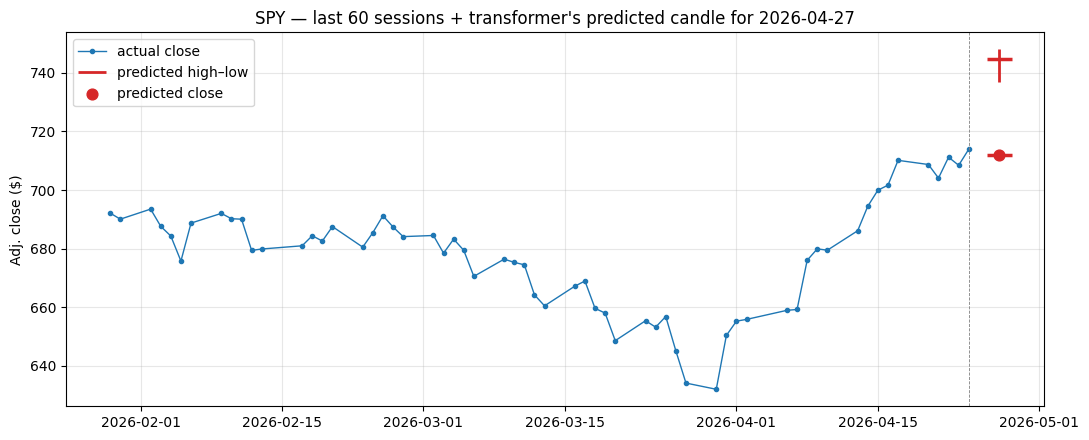

In [13]:
tail = aligned[target_sym].set_index("timestamp").tail(60)
next_date = last_date + pd.tseries.offsets.BDay(1)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(tail.index, tail["close"], color="tab:blue", marker="o", ms=3, lw=1.0, label="actual close")
ax.vlines(next_date, pred_ohlc[2], pred_ohlc[1], color="tab:red", lw=2.0, label="predicted high–low")
ax.plot([next_date], [pred_ohlc[0]], marker="_", ms=18, color="tab:red", mew=2.5)
ax.plot([next_date], [pred_ohlc[3]], marker="_", ms=18, color="tab:red", mew=2.5)
ax.scatter([next_date], [pred_ohlc[3]], color="tab:red", s=60, zorder=5, label="predicted close")
ax.axvline(last_date, color="gray", lw=0.6, ls="--")
ax.set_title(f"{target_sym} — last 60 sessions + transformer's predicted candle for {next_date.date()}")
ax.set_ylabel("Adj. close ($)")
ax.grid(alpha=0.3)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Done.

Knobs to play with:

- `cfg["symbols"]` — try a wider basket (any ticker present in `data/processed/ohlcv.parquet`).
- `cfg["start_date"]` — restricting to a single regime (post-2010, post-2015, etc.) often changes results dramatically.
- `cfg["lookback"]`, `d_model`, `nhead`, `num_layers` — capacity vs. sample efficiency.
- `cfg["target_symbol"]` — the model can predict any aligned symbol's next-day candle.

For a different cached universe, edit `cfg["symbols"]` and re-run from §1.